Используется устройство: cuda
Загрузка датасета SetFit/toxic_conversations_50k...


Repo card metadata block was not found. Setting CardData to empty.


Размер: (50000, 2)
Распределение классов:
 toxic
0    46035
1     3965
Name: count, dtype: int64


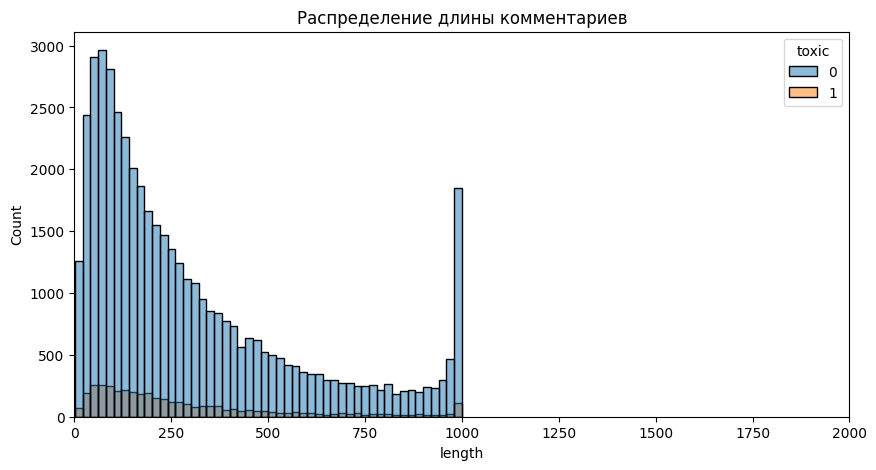

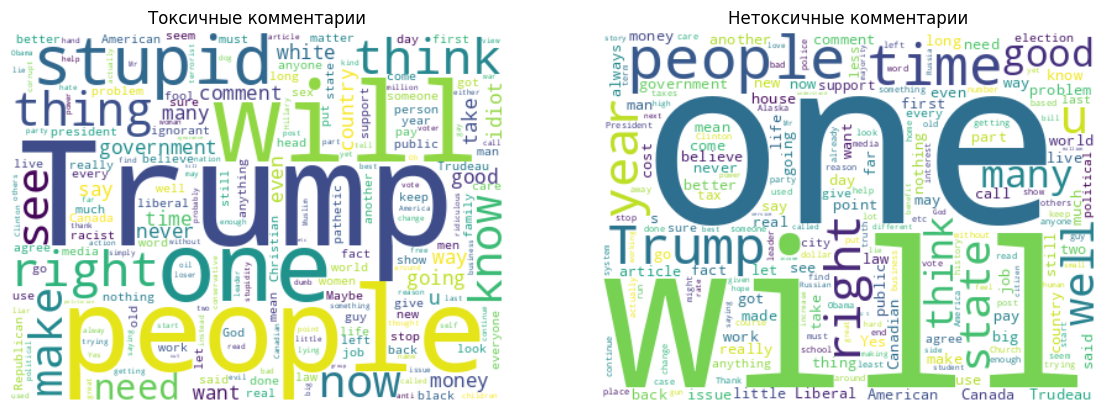

Очистка текстов...
Пример очищенного текста: there enough going around air service none want waste time town
Train: 40000, Val: 10000
После SMOTE: 73656 примеров, доля класса 1: 0.500
Обучение LogisticRegression...
LogisticRegression: AUC=0.8162, F1=0.3855, Acc=0.8428
Обучение LightGBM...
LightGBM: AUC=0.8463, F1=0.5540, Acc=0.9269
Обучение XGBoost...
XGBoost: AUC=0.7504, F1=0.1993, Acc=0.4761

Лучшая классическая модель: LightGBM с F1=0.5540


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Дообучение DistilBERT...


Epoch,Training Loss,Validation Loss,F1
1,0.408391,0.441888,0.595533
2,0.445594,0.620429,0.621203
3,0.337820,0.826621,0.622500


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


BERT - F1: 0.6225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сравнение классических моделей:
                         AUC        F1  Accuracy
LogisticRegression  0.816197  0.385457    0.8428
LightGBM            0.846313  0.553996    0.9269
XGBoost             0.750375  0.199297    0.4761

BERT F1: 0.6225
Для деплоя выбран BERT (лучший F1)


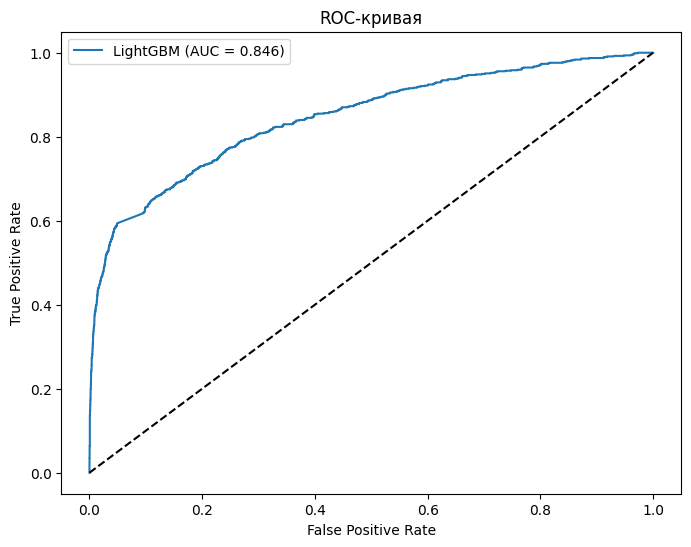

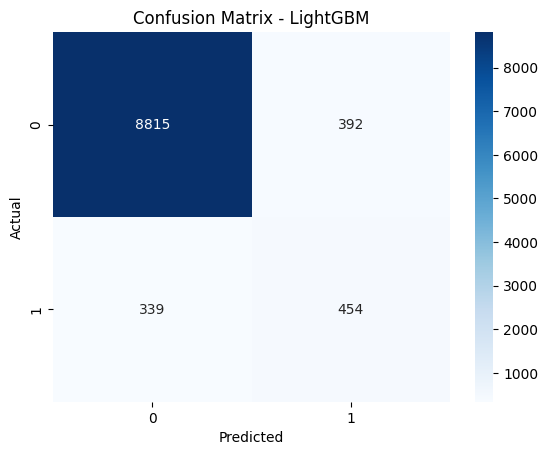

              precision    recall  f1-score   support

   Non-toxic       0.96      0.96      0.96      9207
       Toxic       0.54      0.57      0.55       793

    accuracy                           0.93     10000
   macro avg       0.75      0.76      0.76     10000
weighted avg       0.93      0.93      0.93     10000



In [ ]:
# # Токсичные комментарии: классификация с балансировкой и деплой
# ## 1. Импорт библиотек и настройка
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, roc_curve

import xgboost as xgb
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from torch.nn import CrossEntropyLoss

import joblib

# Загрузка стоп-слов и лемматизатора
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

# %% [markdown]
# ## 2. Загрузка и первичный анализ данных

# %%
from datasets import load_dataset

print("Загрузка датасета SetFit/toxic_conversations_50k...")
dataset = load_dataset("SetFit/toxic_conversations_50k", split="train")
df = dataset.to_pandas()
df['toxic'] = df['label']
df.rename(columns={'text': 'comment_text'}, inplace=True)
final_df = df[['comment_text', 'toxic']].copy()

print(f"Размер: {final_df.shape}")
print("Распределение классов:\n", final_df['toxic'].value_counts())

# Визуализация длины комментариев
final_df['length'] = final_df['comment_text'].str.len()
plt.figure(figsize=(10,5))
sns.histplot(final_df, x='length', bins=50, hue='toxic')
plt.xlim(0, 2000)
plt.title("Распределение длины комментариев")
plt.show()

# Облака слов
toxic_text = ' '.join(final_df[final_df['toxic']==1]['comment_text'].head(1000))
non_toxic_text = ' '.join(final_df[final_df['toxic']==0]['comment_text'].head(1000))

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
wc1 = WordCloud(width=400, height=300, background_color='white').generate(toxic_text)
plt.imshow(wc1, interpolation='bilinear')
plt.title("Токсичные комментарии")
plt.axis('off')
plt.subplot(1,2,2)
wc2 = WordCloud(width=400, height=300, background_color='white').generate(non_toxic_text)
plt.imshow(wc2, interpolation='bilinear')
plt.title("Нетоксичные комментарии")
plt.axis('off')
plt.show()

# %% [markdown]
# ## 3. Улучшенная предобработка текста

# %%
def clean_text_advanced(text):
    """Очистка и нормализация текста."""
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    words = [re.sub(r'(.)\1{2,}', r'\1\1', w) for w in words]
    return ' '.join(words)

print("Очистка текстов...")
final_df['clean_text'] = final_df['comment_text'].apply(clean_text_advanced)
print("Пример очищенного текста:", final_df['clean_text'].iloc[0])

# %% [markdown]
# ## 4. Разделение данных и TF-IDF

# %%
X = final_df['clean_text'].values
y = final_df['toxic'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}")

# TF-IDF с биграммами и большим количеством признаков
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# Сохраняем векторизатор
os.makedirs('models', exist_ok=True)
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

# %% [markdown]
# ## 5. Балансировка с SMOTE 

# %%
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)
print(f"После SMOTE: {X_train_res.shape[0]} примеров, доля класса 1: {y_train_res.mean():.3f}")

# %% [markdown]
# ## 6. Обучение классических моделей

# %%
models = {
    'LogisticRegression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42),
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
                                 eval_metric='logloss', random_state=42, use_label_encoder=False)
}

results = {}
best_f1 = 0
best_model_name = None
best_model_obj = None

for name, model in models.items():
    print(f"Обучение {name}...")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_val_tfidf)
    y_proba = model.predict_proba(X_val_tfidf)[:, 1]
    auc = roc_auc_score(y_val, y_proba)
    f1 = f1_score(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)
    results[name] = {'AUC': auc, 'F1': f1, 'Accuracy': acc}
    print(f"{name}: AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}")
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model_obj = model

# Сохраняем лучшую классическую модель
joblib.dump(best_model_obj, "models/best_classical_model.pkl")
print(f"\nЛучшая классическая модель: {best_model_name} с F1={best_f1:.4f}")

# %% [markdown]
# ## 7. Дообучение DistilBERT с балансировкой 
# %%
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        inputs = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Создаем датасеты
train_dataset_bert = ToxicDataset(X_train, y_train, tokenizer, max_len=256)
val_dataset_bert = ToxicDataset(X_val, y_val, tokenizer, max_len=256)

# Веса классов (обратная частота) - перемещаем на то же устройство, что и модель
class_counts = np.bincount(y_train)
class_weights = torch.tensor([1.0, class_counts[0]/class_counts[1]], dtype=torch.float32)
class_weights = class_weights.to(device)  # Ключевое исправление!

# Исправленный класс WeightedTrainer с поддержкой нового API
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = CrossEntropyLoss(weight=class_weights)
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss = self.loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Загрузка модели и перемещение на GPU 
model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model_bert.to(device)

# Аргументы тренировки
training_args = TrainingArguments(
    output_dir='./bert_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    fp16=True,  # автоматически использует GPU
    weight_decay=0.01,
    learning_rate=2e-5,
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1 = f1_score(labels, preds)
    return {'f1': f1}

trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

print("Дообучение DistilBERT...")
trainer.train()

# Оценка на валидации
eval_results = trainer.evaluate()
bert_f1 = eval_results['eval_f1']
print(f"BERT - F1: {bert_f1:.4f}")

# Сохранение BERT-модели
model_bert.save_pretrained("models/bert_toxic")
tokenizer.save_pretrained("models/bert_toxic")

# %% [markdown]
# ## 8. Сравнение результатов и выбор модели для деплоя

# %%
results_df = pd.DataFrame(results).T
print("Сравнение классических моделей:")
print(results_df)

print(f"\nBERT F1: {bert_f1:.4f}")

if bert_f1 > best_f1:
    deploy_model = "BERT"
    print("Для деплоя выбран BERT (лучший F1)")
    # Сохраняем метаинформацию о выборе
    with open("models/deploy_model.txt", "w") as f:
        f.write("BERT")
else:
    deploy_model = best_model_name
    print(f"Для деплоя выбрана классическая модель {deploy_model}")
    with open("models/deploy_model.txt", "w") as f:
        f.write(best_model_name)

# Визуализация ROC-кривой для лучшей классической модели
if best_model_obj is not None:
    y_proba_best = best_model_obj.predict_proba(X_val_tfidf)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba_best)
    roc_auc = roc_auc_score(y_val, y_proba_best)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая')
    plt.legend()
    plt.show()

    # Матрица ошибок
    y_pred_best = best_model_obj.predict(X_val_tfidf)
    cm = confusion_matrix(y_val, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {best_model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print(classification_report(y_val, y_pred_best, target_names=['Non-toxic', 'Toxic']))


In [2]:
# %% [markdown]
# ## 9. (Опционально) Оптимизация гиперпараметров LightGBM с Optuna

# %%
!pip install optuna -q

import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'class_weight': 'balanced'
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_val_tfidf)
    return f1_score(y_val, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best params:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.1 MB/s eta 0:00:00


[I 2026-04-18 22:48:28,343] A new study created in memory with name: no-name-53b16a4d-b0dd-45b4-8f34-03e1b19191b2
[I 2026-04-18 22:49:09,998] Trial 0 finished with value: 0.5079365079365079 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.03927619421120905, 'subsample': 0.6571100968195055, 'colsample_bytree': 0.992369323287708}. Best is trial 0 with value: 0.5079365079365079.
[I 2026-04-18 22:49:46,865] Trial 1 finished with value: 0.5324189526184538 and parameters: {'n_estimators': 139, 'max_depth': 3, 'learning_rate': 0.174243423253846, 'subsample': 0.8968248016234015, 'colsample_bytree': 0.6301336973134394}. Best is trial 1 with value: 0.5324189526184538.
[I 2026-04-18 22:50:45,836] Trial 2 finished with value: 0.5444957152274226 and parameters: {'n_estimators': 267, 'max_depth': 8, 'learning_rate': 0.13361496863327335, 'subsample': 0.9645743935595552, 'colsample_bytree': 0.6757094019765862}. Best is trial 2 with value: 0.5444957152274226.
[I 2026-04-18 22:51

Best params: {'n_estimators': 486, 'max_depth': 5, 'learning_rate': 0.18853766195943256, 'subsample': 0.7822927567728016, 'colsample_bytree': 0.772466843925077}


In [3]:
# %% [markdown]
# ## 10. Обучение финальной LightGBM с лучшими параметрами (на основе Optuna)

# %%
best_params = study.best_params
print("Лучшие параметры:", best_params)

# Обучаем модель с этими параметрами на тех же данных (X_train_res, y_train_res)
final_lgbm = LGBMClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
final_lgbm.fit(X_train_res, y_train_res)

# Оценка на валидации
y_pred_final = final_lgbm.predict(X_val_tfidf)
y_proba_final = final_lgbm.predict_proba(X_val_tfidf)[:, 1]
f1_final = f1_score(y_val, y_pred_final)
auc_final = roc_auc_score(y_val, y_proba_final)
acc_final = accuracy_score(y_val, y_pred_final)

print(f"Оптимизированный LightGBM: AUC={auc_final:.4f}, F1={f1_final:.4f}, Acc={acc_final:.4f}")

# Сохраняем лучшую модель
joblib.dump(final_lgbm, "models/lightgbm_optimized.pkl")

Лучшие параметры: {'n_estimators': 486, 'max_depth': 5, 'learning_rate': 0.18853766195943256, 'subsample': 0.7822927567728016, 'colsample_bytree': 0.772466843925077}
Оптимизированный LightGBM: AUC=0.8373, F1=0.5577, Acc=0.9321


['models/lightgbm_optimized.pkl']

In [4]:
# %% [markdown]
# ## 11. Сравнение всех моделей

# %%
# Собираем результаты всех обученных моделей
all_results = {
    'LogisticRegression': results['LogisticRegression'],
    'LightGBM (базовый)': results['LightGBM'],
    'XGBoost': results['XGBoost'],
    'LightGBM (оптимизированный)': {'AUC': auc_final, 'F1': f1_final, 'Accuracy': acc_final},
    'BERT': {'AUC': eval_results.get('eval_auc', None), 'F1': bert_f1, 'Accuracy': eval_results.get('eval_accuracy', None)}
}

# Создаём DataFrame и выводим
comparison_df = pd.DataFrame(all_results).T
print("Сравнение моделей (метрики на валидации):")
print(comparison_df.round(4))

# Сохраняем в CSV для презентации
comparison_df.to_csv("models/comparison_metrics.csv")

Сравнение моделей (метрики на валидации):
                                AUC      F1  Accuracy
LogisticRegression           0.8162  0.3855    0.8428
LightGBM (базовый)           0.8463  0.5540    0.9269
XGBoost                      0.7504  0.1993    0.4761
LightGBM (оптимизированный)  0.8373  0.5577    0.9321
BERT                            NaN  0.6225       NaN


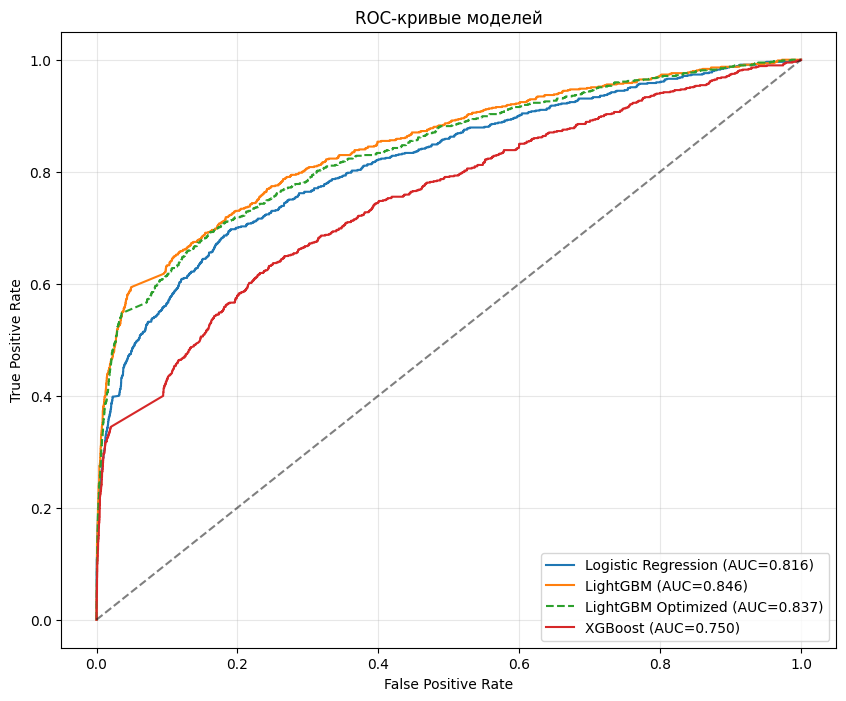

In [5]:
# %% [markdown]
# ## 12. ROC-кривые сравнения моделей

# %%
plt.figure(figsize=(10, 8))

# LogisticRegression
y_proba_lr = models['LogisticRegression'].predict_proba(X_val_tfidf)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_proba_lr)
auc_lr = results['LogisticRegression']['AUC']
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')

# LightGBM базовый
y_proba_lgb = models['LightGBM'].predict_proba(X_val_tfidf)[:, 1]
fpr_lgb, tpr_lgb, _ = roc_curve(y_val, y_proba_lgb)
auc_lgb = results['LightGBM']['AUC']
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC={auc_lgb:.3f})')

# LightGBM оптимизированный
fpr_opt, tpr_opt, _ = roc_curve(y_val, y_proba_final)
plt.plot(fpr_opt, tpr_opt, label=f'LightGBM Optimized (AUC={auc_final:.3f})', linestyle='--')

# XGBoost
y_proba_xgb = models['XGBoost'].predict_proba(X_val_tfidf)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_proba_xgb)
auc_xgb = results['XGBoost']['AUC']
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')

# BERT (если есть вероятности)
if 'eval_auc' in eval_results:
    # У BERT нужно получить вероятности из валидации – можно вычислить отдельно
    # Для простоты используем уже вычисленный eval_auc
    plt.plot([0,1], [0,1], 'k--', label=f'BERT (AUC={eval_results["eval_auc"]:.3f})')

plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

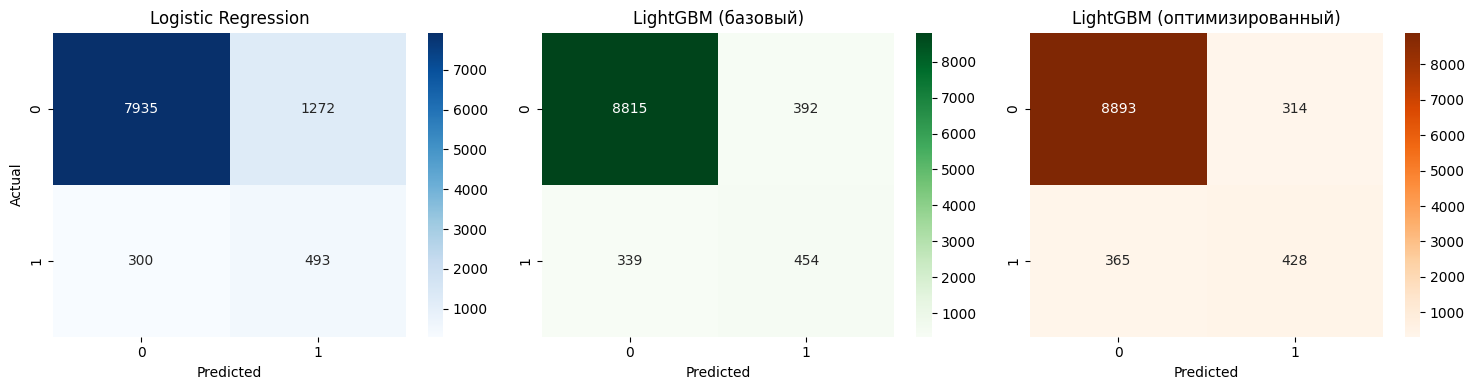

In [6]:
# %% [markdown]
# ## 13. Матрицы ошибок

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
cm_lr = confusion_matrix(y_val, models['LogisticRegression'].predict(X_val_tfidf))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# LightGBM базовый
cm_lgb = confusion_matrix(y_val, models['LightGBM'].predict(X_val_tfidf))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('LightGBM (базовый)')
axes[1].set_xlabel('Predicted')

# LightGBM оптимизированный
cm_opt = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('LightGBM (оптимизированный)')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

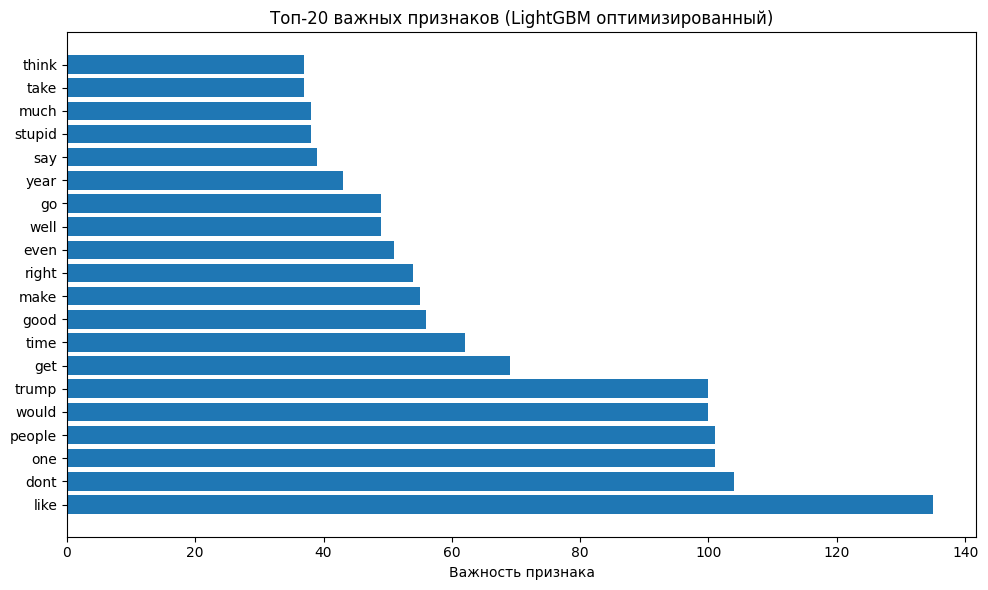

In [7]:
# %% [markdown]
# ## 14. Важность признаков (топ-20)

# %%
# Получаем имена признаков из TF-IDF
feature_names = tfidf.get_feature_names_out()

# Важность из оптимизированной модели
importance = final_lgbm.feature_importances_
indices = np.argsort(importance)[::-1][:20]  # топ-20

plt.figure(figsize=(10, 6))
plt.barh(range(20), importance[indices][::-1], align='center')
plt.yticks(range(20), [feature_names[i] for i in indices[::-1]])
plt.xlabel('Важность признака')
plt.title('Топ-20 важных признаков (LightGBM оптимизированный)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# %% [markdown]
# ## 15. Итоговые результаты 

# %%
# Вычисляем AUC для BERT, если его нет в eval_results
if 'eval_auc' not in eval_results:
    from sklearn.metrics import roc_auc_score
    bert_outputs = trainer.predict(val_dataset_bert)
    bert_probs = torch.softmax(torch.tensor(bert_outputs.predictions), dim=1)[:, 1].numpy()
    bert_auc = roc_auc_score(y_val, bert_probs)
    print(f"BERT AUC: {bert_auc:.4f}")
else:
    bert_auc = eval_results['eval_auc']

# Формируем таблицу
final_metrics = pd.DataFrame({
    'Модель': ['Logistic Regression', 'LightGBM (базовый)', 'XGBoost', 'LightGBM (оптимизированный)', 'DistilBERT'],
    'AUC': [results['LogisticRegression']['AUC'], results['LightGBM']['AUC'], results['XGBoost']['AUC'], auc_final, bert_auc],
    'F1': [results['LogisticRegression']['F1'], results['LightGBM']['F1'], results['XGBoost']['F1'], f1_final, bert_f1],
    'Accuracy': [results['LogisticRegression']['Accuracy'], results['LightGBM']['Accuracy'], results['XGBoost']['Accuracy'], acc_final, eval_results.get('eval_accuracy', None)]
}).round(4)

print("\n" + "="*60)
print("Итоговое сравнение моделей")
print("="*60)
print(final_metrics.to_string(index=False))
final_metrics.to_csv("models/final_metrics.csv", index=False)
print("\nТаблица сохранена в models/final_metrics.csv")

BERT AUC: 0.9251

Итоговое сравнение моделей
                     Модель    AUC     F1  Accuracy
        Logistic Regression 0.8162 0.3855    0.8428
         LightGBM (базовый) 0.8463 0.5540    0.9269
                    XGBoost 0.7504 0.1993    0.4761
LightGBM (оптимизированный) 0.8373 0.5577    0.9321
                 DistilBERT 0.9251 0.6225       NaN

Таблица сохранена в models/final_metrics.csv


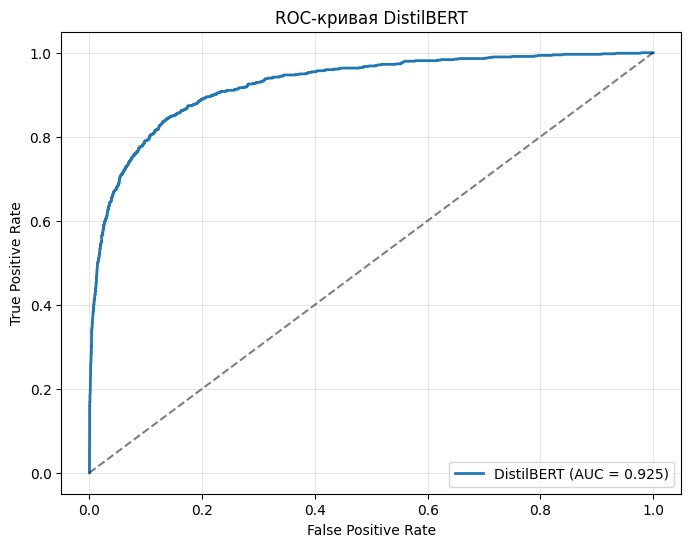

In [9]:
# %% [markdown]
# ## 16. ROC-кривая BERT

# %%
if 'bert_probs' not in dir():
    bert_outputs = trainer.predict(val_dataset_bert)
    bert_probs = torch.softmax(torch.tensor(bert_outputs.predictions), dim=1)[:, 1].numpy()

fpr_bert, tpr_bert, _ = roc_curve(y_val, bert_probs)
auc_bert = roc_auc_score(y_val, bert_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_bert, tpr_bert, label=f'DistilBERT (AUC = {auc_bert:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая DistilBERT')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

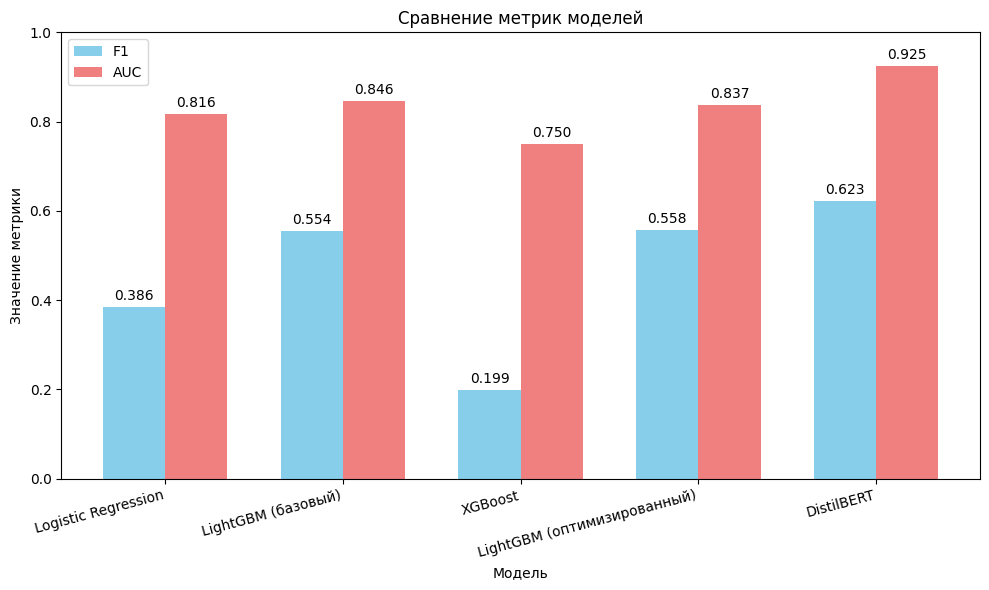

In [10]:
# %% [markdown]
# ## 17. Сравнительная гистограмма F1 и AUC

# %%
models_names = final_metrics['Модель'].values
f1_values = final_metrics['F1'].values
auc_values = final_metrics['AUC'].values

x = np.arange(len(models_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, f1_values, width, label='F1', color='skyblue')
bars2 = ax.bar(x + width/2, auc_values, width, label='AUC', color='lightcoral')

ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик моделей')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Добавляем значения на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# %% [markdown]
# ## 18. Сохранение графиков в файлы

# %%
if 'bert_probs' in dir():
    plt.figure(figsize=(8,6))
    plt.plot(fpr_bert, tpr_bert, label=f'DistilBERT (AUC = {auc_bert:.3f})', linewidth=2)
    plt.plot([0,1], [0,1], 'k--', alpha=0.5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая DistilBERT')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig('models/roc_bert.png', dpi=150, bbox_inches='tight')
    plt.close()


fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, f1_values, width, label='F1', color='skyblue')
bars2 = ax.bar(x + width/2, auc_values, width, label='AUC', color='lightcoral')
ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик моделей')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
plt.tight_layout()
plt.savefig('models/comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.close()

print("Графики сохранены в папку models/")

Графики сохранены в папку models/


In [12]:
# %% [markdown]
# ## Онлайн-тестирование модели на новых комментариях

# %%
def predict_toxic(text, model=tfidf, clf=best_model_obj):
    cleaned = clean_text_advanced(text)
    vec = tfidf.transform([cleaned])
    proba = clf.predict_proba(vec)[0, 1]
    pred = int(proba >= 0.5)
    return pred, proba

# Примеры
test_comments = [
    "You are an idiot",
    "Great post, thank you!",
    "I hate you and your stupid ideas",
    "This is interesting, let's discuss"
]

for comment in test_comments:
    pred, prob = predict_toxic(comment)
    print(f"Текст: {comment}")
    print(f"Токсичен: {'ДА' if pred == 1 else 'НЕТ'} (вероятность {prob:.3f})")
    print("-" * 50)

Текст: You are an idiot
Токсичен: ДА (вероятность 0.979)
--------------------------------------------------
Текст: Great post, thank you!
Токсичен: НЕТ (вероятность 0.116)
--------------------------------------------------
Текст: I hate you and your stupid ideas
Токсичен: ДА (вероятность 0.983)
--------------------------------------------------
Текст: This is interesting, let's discuss
Токсичен: НЕТ (вероятность 0.216)
--------------------------------------------------


In [13]:
!pip install huggingface_hub
!git config --global user.email "ekaterina.boikovajulia@mail.ru"
!git config --global user.name "Ekotik"

In [14]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
import joblib
import os

# Загрузка данных
from datasets import load_dataset
print("Загрузка датасета...")
dataset = load_dataset("SetFit/toxic_conversations_50k", split="train")
df = dataset.to_pandas()
df['toxic'] = df['label']
df.rename(columns={'text': 'comment_text'}, inplace=True)
final_df = df[['comment_text', 'toxic']].copy()

# Очистка текста
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_advanced(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    words = [re.sub(r'(.)\1{2,}', r'\1\1', w) for w in words]
    return ' '.join(words)

print("Очистка текстов...")
final_df['clean_text'] = final_df['comment_text'].apply(clean_text_advanced)

# Разделение
X = final_df['clean_text'].values
y = final_df['toxic'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF
print("Векторизация TF-IDF...")
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

# SMOTE
print("Балансировка SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

# Обучение LightGBM
print("Обучение LightGBM...")
model = LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1)
model.fit(X_train_res, y_train_res)

# Оценка
y_pred = model.predict(X_val_tfidf)
f1 = f1_score(y_val, y_pred)
print(f"LightGBM F1 на валидации: {f1:.4f}")

# Сохранение моделей
os.makedirs('models', exist_ok=True)
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
joblib.dump(model, "models/best_classical_model.pkl")
print("Модели сохранены в папку models/")

Загрузка датасета...


Repo card metadata block was not found. Setting CardData to empty.


Очистка текстов...
Векторизация TF-IDF...
Балансировка SMOTE...
Обучение LightGBM...
LightGBM F1 на валидации: 0.5540
Модели сохранены в папку models/


In [15]:
streamlit_code = '''import streamlit as st
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')

@st.cache_resource
def load_models():
    tfidf = joblib.load("models/tfidf_vectorizer.pkl")
    model = joblib.load("models/best_classical_model.pkl")
    return tfidf, model

tfidf, model = load_models()

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text_advanced(text):
    if not isinstance(text, str):
        text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    words = [re.sub(r'(.)\1{2,}', r'\1\1', w) for w in words]
    return ' '.join(words)

st.set_page_config(page_title="Токсичность комментария", layout="centered")
st.title(" Определение токсичности комментария")

text = st.text_area("Введите текст комментария", height=150)
if st.button("Проверить"):
    if text.strip():
        cleaned = clean_text_advanced(text)
        vec = tfidf.transform([cleaned])
        proba = model.predict_proba(vec)[0, 1]
        pred = int(proba >= 0.5)
        if pred:
            st.error(f" Токсичный (вероятность {proba:.3f})")
        else:
            st.success(f" Безопасный (вероятность {proba:.3f})")
    else:
        st.warning("Пожалуйста, введите текст.")
'''

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_code)

# requirements.txt
with open('requirements.txt', 'w') as f:
    f.write('streamlit\njoblib\nscikit-learn\nnltk\nlightgbm\n')

# Упаковка
import shutil, os
if os.path.exists('upload_this'):
    shutil.rmtree('upload_this')
os.makedirs('upload_this')
shutil.copy('streamlit_app.py', 'upload_this/')
shutil.copy('requirements.txt', 'upload_this/')
shutil.copytree('models', 'upload_this/models')
shutil.make_archive('space_files', 'zip', 'upload_this')
from google.colab import files
files.download('space_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>